# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Farhan Hanif Azhary
- **Email:** farhanhanifazhary@gmail.com
- **ID Dicoding:** farhan_hanif_azhary

## Menentukan Pertanyaan Bisnis

- Faktor apa yang paling mempengaruhi jumlah peminjaman sepeda, dan kapan permintaan tertinggi terjadi?
- Bagaimana perbedaan perilaku antara pengguna casual dan registered, dan peluang apa yang ada untuk meningkatkan konversi menjadi pengguna rutin?

## Import Semua Packages/Library yang Digunakan

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Data Wrangling

### Gathering Data

In [6]:
BASE_DIR = Path().resolve()
DATA_PATH = BASE_DIR / "data" / "day.csv"
day_df = pd.read_csv(DATA_PATH)
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- registered lebih banyak dari casual
- cnt relatif lebih tinggi saat workingday
- weathersit terlihat berdampak terhadap cnt
- hum tinggi tidak selalu berdampak terhadap cnt

### Assessing Data

In [7]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
print("Jumlah data duplikat: ", day_df.duplicated().sum())

Jumlah data duplikat:  0


In [9]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Kolom dteday masih bertipe object
- Tidak ada missing values, data duplikat, dan innacurate value

### Cleaning Data

In [10]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"], format="%Y-%m-%d")
day_df["dteday"].dtype

dtype('<M8[ns]')

**Insight:**
- Kolom dteday telah diubah menjadi tipe datetime

## Exploratory Data Analysis (EDA)

### Explore ...

In [11]:
day_df["cnt"].describe()

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

In [12]:
day_df["cnt"].skew()

np.float64(-0.04735278011900183)

In [13]:
day_df.nlargest(5, "cnt")[["dteday","cnt","temp","weathersit","workingday"]]

,dteday,cnt,temp,weathersit,workingday
623,2012-09-15,8714,0.608333,1,0
637,2012-09-29,8555,0.542500,1,0
630,2012-09-22,8395,0.650000,1,0
447,2012-03-23,8362,0.601667,2,1
504,2012-05-19,8294,0.600000,1,0


In [14]:
day_df.nsmallest(5, "cnt")[["dteday","cnt","temp","weathersit","workingday"]]

,dteday,cnt,temp,weathersit,workingday
667,2012-10-29,22,0.440000,3,1
26,2011-01-27,431,0.195000,1,1
725,2012-12-26,441,0.243333,3,1
25,2011-01-26,506,0.217500,3,1
64,2011-03-06,605,0.376522,2,0


In [15]:
day_df.groupby("workingday")["cnt"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
    sum="sum",
    cv=lambda x: x.std() / x.mean()
)

,mean,median,std,count,sum,cv
workingday,,,,,,
0,4330.168831,4459.0,2052.141245,231,1000269,0.473917
1,4584.820000,4582.0,1878.415583,500,2292410,0.409703


In [16]:
day_df.groupby("season")["cnt"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
    sum="sum",
    cv=lambda x: x.std() / x.mean()
)

,mean,median,std,count,sum,cv
season,,,,,,
1,2604.132597,2209.0,1399.942119,181,471348,0.537585
2,4992.331522,4941.5,1695.977235,184,918589,0.339716
3,5644.303191,5353.5,1459.800381,188,1061129,0.258633
4,4728.162921,4634.5,1699.615261,178,841613,0.359466


In [17]:
day_df.groupby("weathersit")["cnt"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
    sum="sum",
    cv=lambda x: x.std() / x.mean()
)

,mean,median,std,count,sum,cv
weathersit,,,,,,
1,4876.786177,4844.0,1879.483989,463,2257952,0.385394
2,4035.862348,4040.0,1809.109918,247,996858,0.448259
3,1803.285714,1817.0,1240.284449,21,37869,0.687791


In [18]:
day_df[["cnt", "temp", "atemp", "hum", "windspeed"]].corr()["cnt"].sort_values(ascending=False)

cnt          1.000000
atemp        0.631066
temp         0.627494
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64

In [19]:
day_df[["casual","registered"]].sum()

casual         620017
registered    2672662
dtype: int64

In [20]:
day_df["registered"].sum() / day_df["casual"].sum()

np.float64(4.310626966679946)

**Insight:**
- Distribusi data relatif simetris ditandai dengan mean dan median yang hampir sama
- Skew hampir 0
- Std cukup besar untuk cnt sekitar 43% dari mean. Ini artinya demand cukup fluktuatif
- Demand tertinggi terjadi saat weathersit = 1 dan 2 (cuaca baik), mayoritas terjadi di non-working day, dan suhu moderat
- Demand terendah terjadi saat suhu relatif rendah
- workingday memiliki mean lebih tinggi, frekuensi lebih sering, dan total cnt 2x dari non-workingday
- season 3 (fall) tertinggi dan paling stabil ditandai dengan cv lebih kecil
- season 1 (springer) terendah dan plaing fluktuatif
- weathersit 3 (light snow/light rain) memiliki demand yang turun sangat banyak dibanding weathersit 1 dan 2. Frekunsinya juga sangat kecil sehingga kontribusi totalnya terhadap sistem rendah.
- Temperatur memiliki korelasi positi kuat terhadap jumlah rental.
- Sistem didominasi oleh pengguna registered (sekitar 81% dari total penggunaan)

## Visualization & Explanatory Analysis

### Pertanyaan 1:

<function matplotlib.pyplot.show(close=None, block=None)>

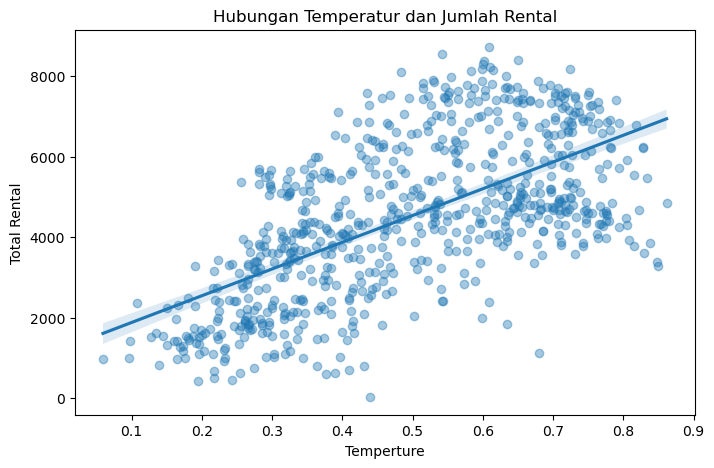

In [21]:
plt.figure(figsize=(8,5))
sns.regplot(data=day_df, x="temp", y="cnt", scatter_kws={"alpha":0.4})
plt.title("Hubungan Temperatur dan Jumlah Rental")
plt.xlabel("Temperture")
plt.ylabel("Total Rental")
plt.show

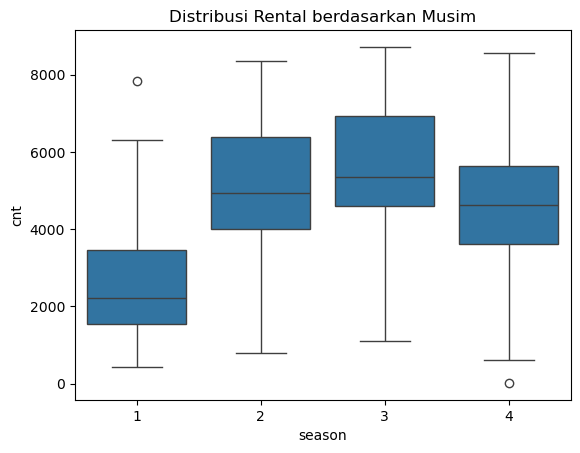

In [22]:
sns.boxplot(data=day_df, x="season", y="cnt")
plt.title("Distribusi Rental berdasarkan Musim")
plt.show()

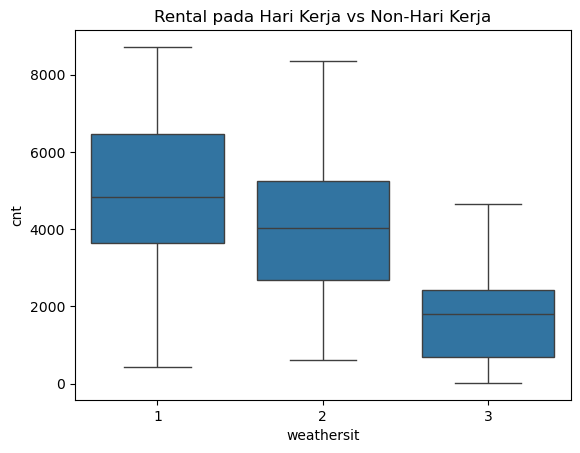

In [23]:
sns.boxplot(data=day_df, x="weathersit", y="cnt")
plt.title("Rental pada Hari Kerja vs Non-Hari Kerja")
plt.show()

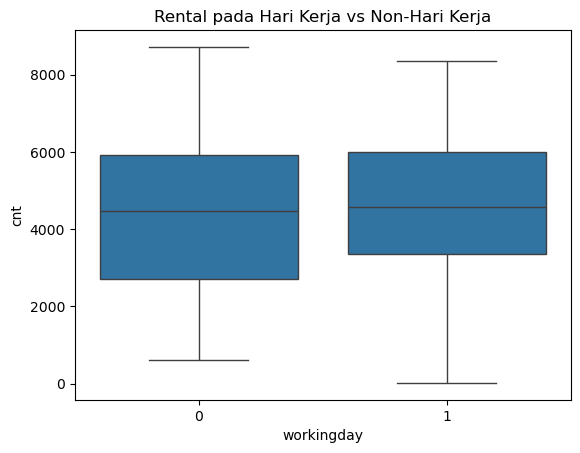

In [24]:
sns.boxplot(data=day_df, x="workingday", y="cnt")
plt.title("Rental pada Hari Kerja vs Non-Hari Kerja")
plt.show()

### Pertanyaan 2:

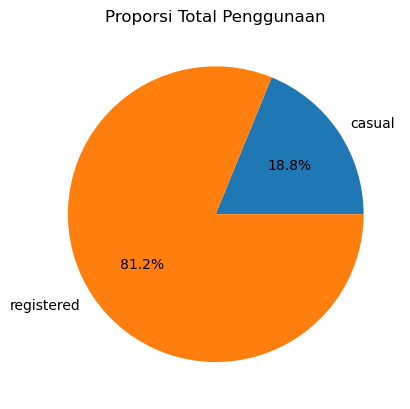

In [25]:
day_df[["casual", "registered"]].sum().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Proporsi Total Penggunaan")
plt.show()

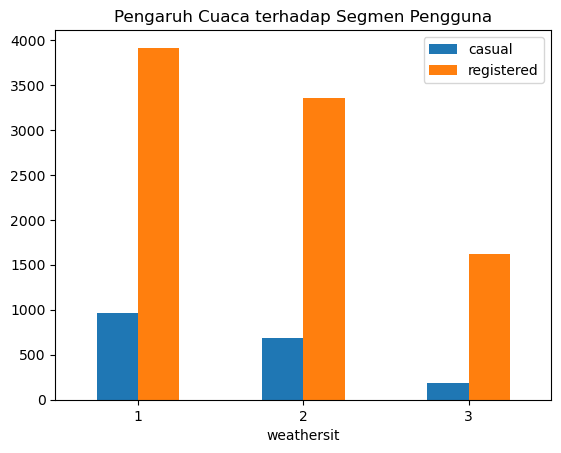

In [26]:
day_df.groupby("weathersit")[["casual","registered"]].mean().plot(kind="bar")
plt.title("Pengaruh Cuaca terhadap Segmen Pengguna")
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Terdapat hubungan positif yang cukup kuat antara temperatur dan jumlah rental. Semakin hangat suhu, semakin tinggi jumlah peminjaman sepeda.
- Musim 3 (Fall) menunjukkan median dan distribusi tertinggi serta variasi yang relatif lebih kecil, menunjukkan musim hangat meningkatkan sekaligus menstabilkan demand.
- Hari kerja memiliki median sedikit lebih tinggi dan variasi lebih rendah dibandingkan non-hari kerja, menunjukkan pola commuting yang konsisten.
- Pengguna registered mendominasi sistem (sekitar 81%), menunjukkan sistem lebih banyak digunakan sebagai transportasi rutin.
- Cuaca yang buruk berpengaruh terhadap pengguna, baik casual maupun registered

## Analisis Lanjutan (Opsional)

## Conclusion

- Suhu menjadi faktor paling mempengaruhi jumlah penyewaan sepeda dilihat dari korelasi temp dan cnt sekitar 63% serta penyewa yang relatif lebih banyak di musim hangat dan cuaca cerah. Pada saat ini juga demand tertinggi terjadi
- Tidak ada perbedaan signifikan antara casual dan registered